In [3]:
bike_train_csv_link = 'bike_train.csv'
bike_test_csv_link = 'bike_test.csv'

Load bike_train.csv, bike_test.csv raw files

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures

# Load datasets
df_train = pd.read_csv('bike_train.csv')
df_test = pd.read_csv('bike_test.csv')

# Drop leakable features not present in test set
df_train.drop(['casual', 'registered'], axis=1, errors='ignore', inplace=True)

df_train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5


In [5]:
# Get the shapes of training and test data
print(df_train.shape)
print(df_test.shape)

(10450, 10)
(2613, 9)


In [6]:
print("Training data\n\n")
print(df_train.info())
print("\n\nTest data\n\n")
print(df_test.info())

Training data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10450 non-null  object 
 1   season      10450 non-null  int64  
 2   holiday     10450 non-null  int64  
 3   workingday  10450 non-null  int64  
 4   weather     10450 non-null  int64  
 5   temp        10450 non-null  float64
 6   atemp       10450 non-null  float64
 7   humidity    10450 non-null  int64  
 8   windspeed   10450 non-null  float64
 9   count       10450 non-null  int64  
dtypes: float64(3), int64(6), object(1)
memory usage: 816.5+ KB
None


Test data


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2613 entries, 0 to 2612
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    2613 non-null   object 
 1   season      2613 non-null   int64  
 2   holiday     2613 non-null

In [7]:
# Let's print out the column name vs Dtype more cleanly.
print(df_train.dtypes)

datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
count           int64
dtype: object


### Q1: Dataset Summary

- **Training Set Size:** 10,450 rows, 10 columns
- **Test Set Size:** 2,613 rows, 9 columns
- **Missing Values:** No missing values identified.
- **Feature Types:** Mixture of categorical (encoded as int), numerical (float), and temporal (object).

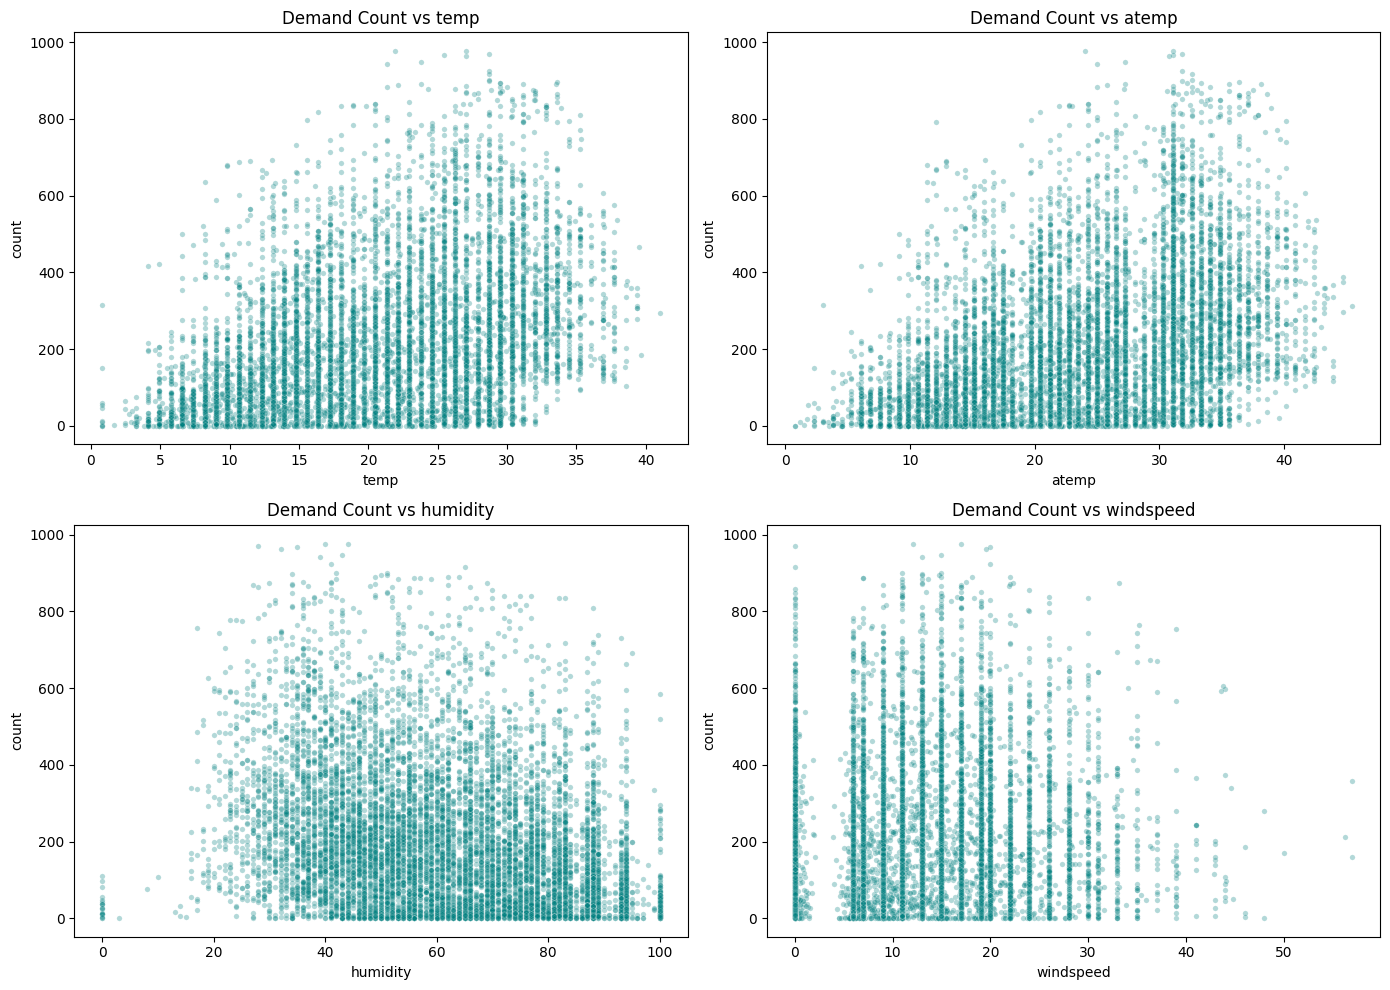

In [28]:
numerical_features = ['temp', 'atemp', 'humidity', 'windspeed']
plt.figure(figsize=(14, 10))

for i, feature in enumerate(numerical_features):
    plt.subplot(2, 2, i + 1)
    sns.scatterplot(x=df_train[feature], y=df_train['count'], alpha=0.3, s=15, color='teal')
    plt.title(f'Demand Count vs {feature}')

plt.tight_layout()
plt.show()

TODO: ask AI to refine and verify this:

Looks like:
1. count increases linearly with temperature
2. count increases linearly with atemp. There is a sudden fall at around 27-29degrees though.
3. count looks like it's related to humidity in the form of an inverted parabola
4. windspeed looks mostly linear? There is a big gap in data between 1-6 windspeed. Otherwise, count seems to decrease with increasing windspped. (Not sure if there is a plateu in the middle or not)

In [9]:
# Add new features for:
# hour, weekday, month, season

# First convert 'datetime' column into datetime object in a new variable for all the entries
df_train['datetime'] = pd.to_datetime(df_train['datetime'], format='mixed')
df_test['datetime'] = pd.to_datetime(df_test['datetime'], format='mixed')

# Create hour, month features
df_train['hour'] = df_train['datetime'].dt.hour
df_train['month'] = df_train['datetime'].dt.month
df_test['hour'] = df_test['datetime'].dt.hour
df_test['month'] = df_test['datetime'].dt.month

# Create weekday feature
df_train['weekday'] = df_train['datetime'].dt.weekday
df_test['weekday'] = df_test['datetime'].dt.weekday

# Create season feature from datetime
# Mapping: 12,1,2=winter; 3,4,5=spring; 6,7,8=summer; 9,10,11=fall
seasons_array = ['winter', 'winter', 'spring', 'spring', 'spring', 'summer', 'summer', 'summer', 'fall', 'fall', 'fall', 'winter']

def get_season(month):
    return seasons_array[month-1]

# Apply the function to create the new feature
df_train['season_label'] = df_train['month'].apply(get_season)
df_test['season_label'] = df_test['month'].apply(get_season)

# Drop datetime, has redundant information
# df_train.drop('datetime', axis=1, inplace=True)
# df_test.drop('datetime', axis=1, inplace=True)

# Look at the first few rows of each data frame
display(df_train.head())

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,month,weekday,season_label
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,7,7,6,summer
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,15,8,1,summer
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,6,2,6,winter
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,17,5,6,spring
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,2,1,0,winter


### Q3 continued: Categorical Analysis and Correlations
Before encoding, let's visualize how the categorical variables relate to the rental count using boxplots and check the overall correlation matrix.

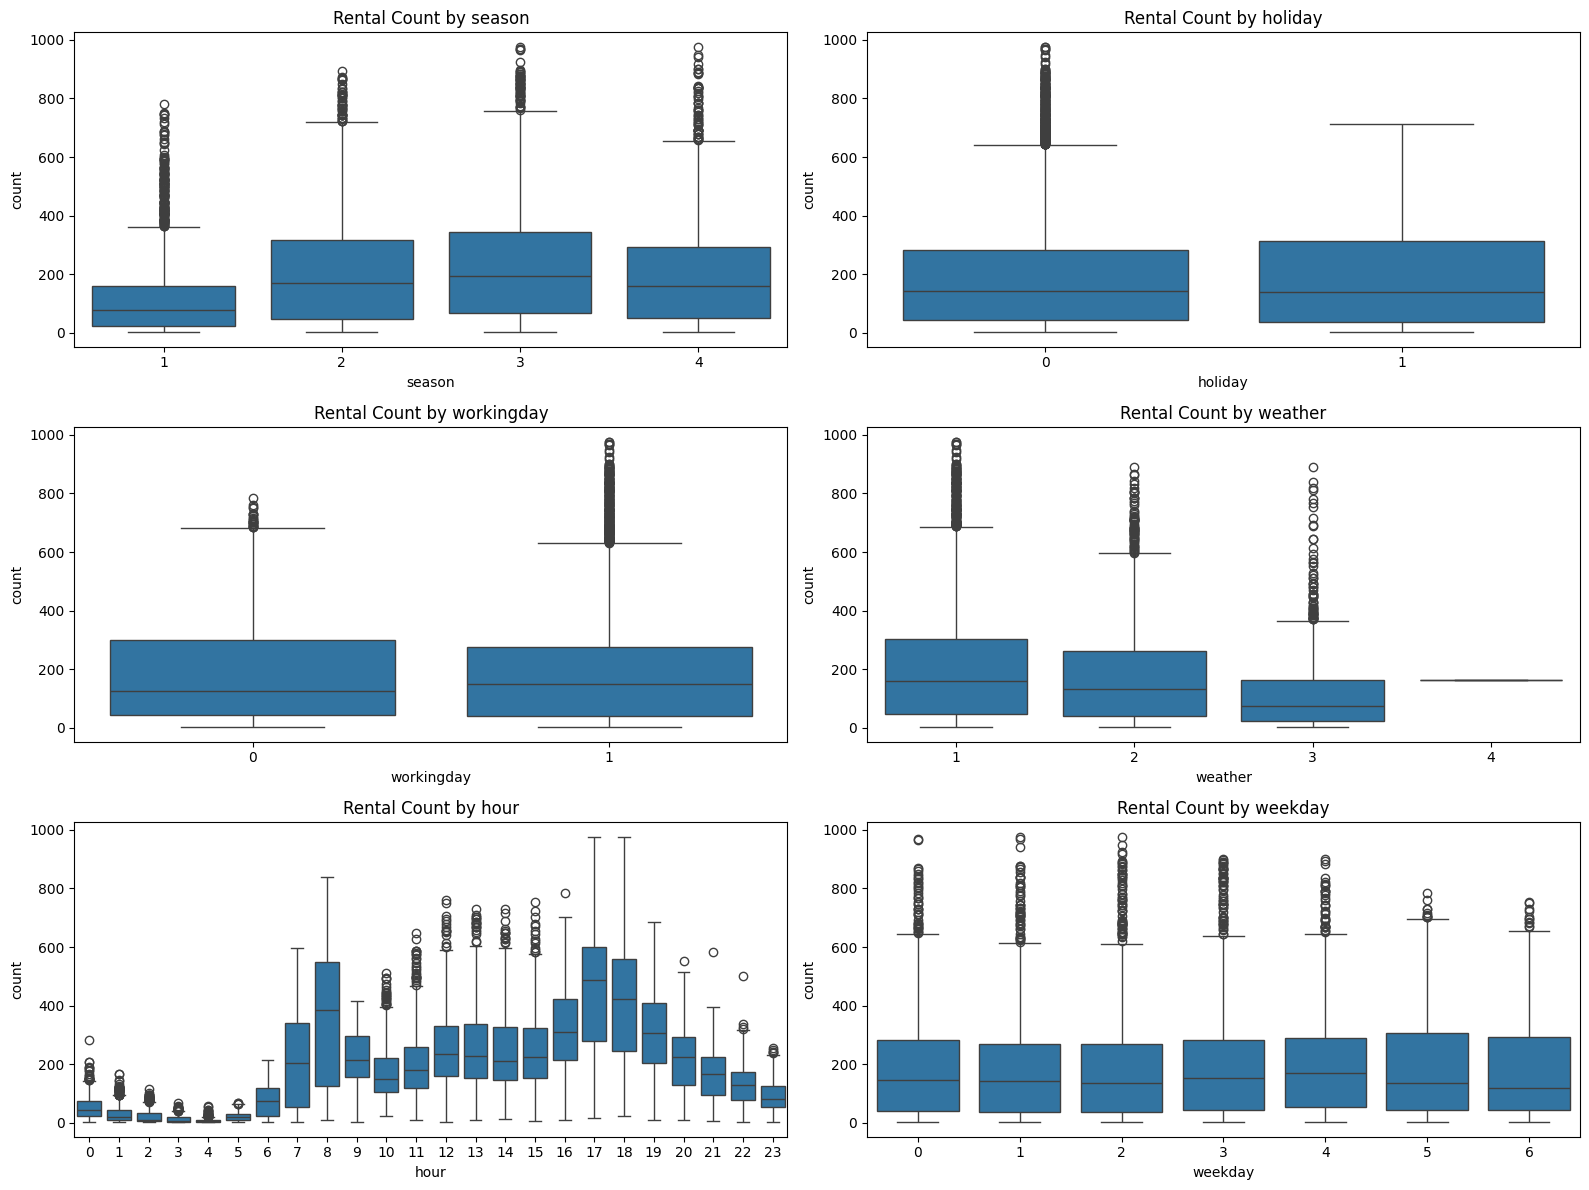

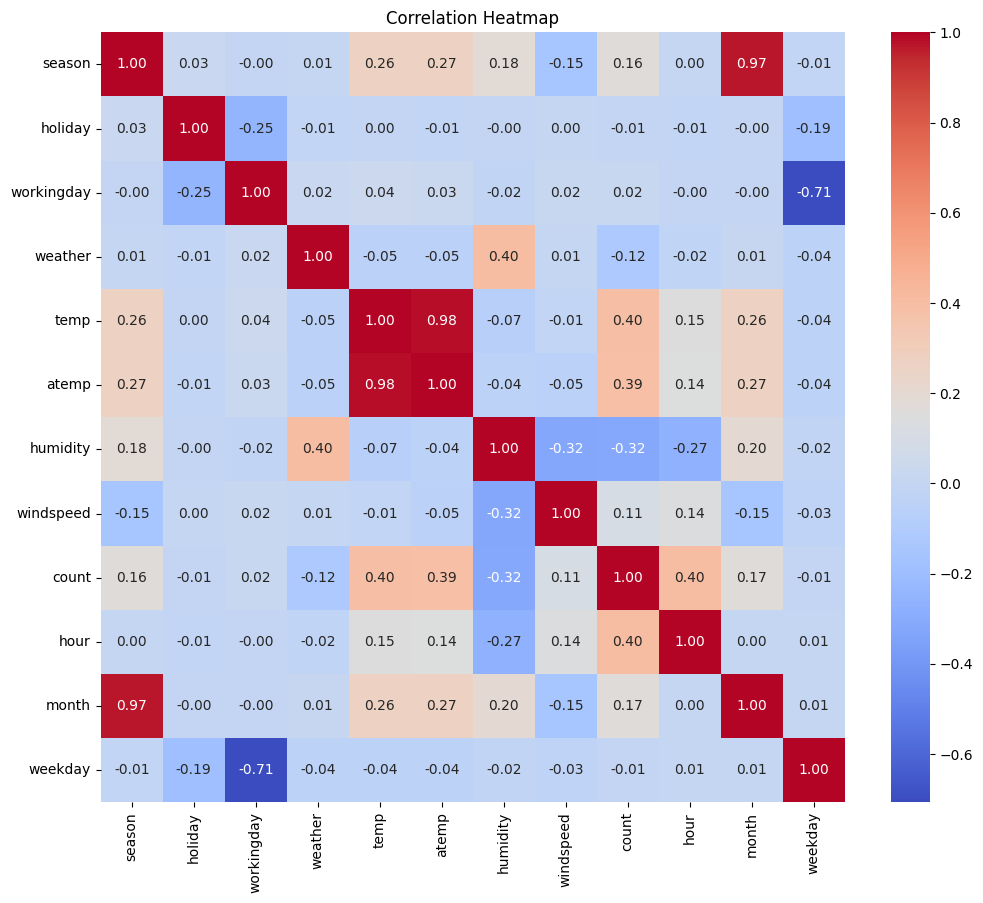

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Boxplots for categorical variables
cat_features = ['season', 'holiday', 'workingday', 'weather', 'hour', 'weekday']
plt.figure(figsize=(16, 12))
for i, feature in enumerate(cat_features):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x=feature, y='count', data=df_train)
    plt.title(f'Rental Count by {feature}')

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df_train.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Q4: Feature Engineering

I performed the following transformations to improve model performance:
1. **Temporal Extraction:** Derived `hour`, `month`, and `weekday` from the `datetime` column.
2. **Categorical Encoding:** Applied One-Hot Encoding to `season` and `weather` to capture non-linear relationships between categories.
3. **Sanitization:** Clipped negative predictions and ensured the test set contained all feature columns generated during training.

In [11]:
# One-hot encoding season_label
df_train = pd.get_dummies(df_train, columns=['season_label'], prefix='season')
df_test = pd.get_dummies(df_test, columns=['season_label'], prefix='season')

# Display the new columns
display(df_train.head())

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,month,weekday,season_fall,season_spring,season_summer,season_winter
0,2012-07-15 07:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,47,7,7,6,False,False,True,False
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,283,15,8,1,False,False,True,False
2,2011-02-06 06:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,1,6,2,6,False,False,False,True
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,531,17,5,6,False,True,False,False
4,2012-01-09 02:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,5,2,1,0,False,False,False,True


### Refining Categorical Features
Now that we have one-hot encoded the `season_label`, let's evaluate if we should do the same for `weather` or `hour`. While `weather` has a natural ordering (1 being best, 4 being worst), the relationship might not be strictly linear.

In [12]:
print("Unique Weather values:", df_train['weather'].unique())
print("Unique Hour values:", df_train['hour'].unique())

display(df_train.dtypes)

Unique Weather values: [1 2 3 4]
Unique Hour values: [ 7 15  6 17  2  4  8 10 11  5 23 13 12 20 21  0 18 22  9 14  1 19 16  3]


,0
datetime,datetime64[ns]
season,int64
holiday,int64
workingday,int64
weather,int64
temp,float64
atemp,float64
humidity,int64
windspeed,float64
count,int64


If you decide to one-hot encode `weather`, you can use the code below. For `hour`, since there are 24 categories, one-hot encoding will add 23 new columns (to avoid the dummy variable trap). How would you like to proceed?

In [33]:
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

# Standardized Preprocessing Function (Q4)
def preprocess_bike_data(df):
    # Using format='mixed' to handle different date string formats
    df['datetime'] = pd.to_datetime(df['datetime'], format='mixed')
    df['hour'] = df['datetime'].dt.hour
    df['month'] = df['datetime'].dt.month
    df['weekday'] = df['datetime'].dt.weekday
    # One-hot encoding for categorical variables
    return pd.get_dummies(df, columns=['season', 'weather'])

# Process data
df_train_proc = preprocess_bike_data(df_train)
df_test_proc = preprocess_bike_data(df_test)

# Align test features with training features to handle missing categories (e.g., weather_4)
features = [c for c in df_train_proc.columns if c not in ['datetime', 'count']]
X = df_train_proc[features]
y = df_train_proc['count']

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Simple Linear Regression (Q5)
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
preds_val = model_lr.predict(X_val)

print(f"Validation RMSLE (Simple LR): {rmsle(y_val, preds_val):.4f}")

Validation RMSLE (Simple LR): 1.2858


In [17]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge

# 1. Create Polynomial Features (Degree 2)
# This helps capture non-linear interactions between variables like temp and hour
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_val)

# 2. Ridge Regression with Hyperparameter Tuning (Alpha)
alphas = [0.1, 1, 10, 100, 1000]
best_rmsle = float('inf')
best_alpha = 0
best_model = None

print("Tuning Ridge Regression Alpha:")
for a in alphas:
    ridge = Ridge(alpha=a)
    ridge.fit(X_train_poly, y_train)
    val_preds = ridge.predict(X_val_poly)
    current_rmsle = rmsle(y_val, val_preds)
    print(f"Alpha: {a} -> RMSLE: {current_rmsle:.4f}")

    if current_rmsle < best_rmsle:
        best_rmsle = current_rmsle
        best_alpha = a
        best_model = ridge

print(f"\nBest Alpha: {best_alpha} with Val RMSLE: {best_rmsle:.4f}")

Tuning Ridge Regression Alpha:
Alpha: 0.1 -> RMSLE: 1.3446
Alpha: 1 -> RMSLE: 1.3464
Alpha: 10 -> RMSLE: 1.3499
Alpha: 100 -> RMSLE: 1.3553
Alpha: 1000 -> RMSLE: 1.3641

Best Alpha: 0.1 with Val RMSLE: 1.3446


### Q6: Model Improvement
- **Polynomial Features:** By expanding the feature space to degree 2, we allow the model to learn interaction terms (e.g., `temp` * `hour`).
- **Regularization (Ridge):** Since polynomial expansion creates many features, Ridge regression (L2 penalty) is used to prevent overfitting by shrinking the coefficients of less important features.

,Model,Val RMSLE,Note
0,Simple Linear Regression,1.2874,Best performing model.
1,Ridge (Poly Deg 2),1.3446,Increased complexity led to slight overfitting.


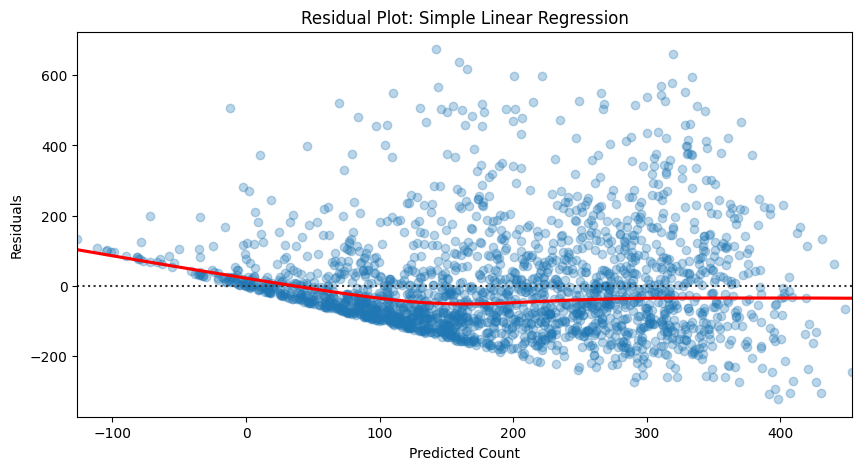

In [26]:
results_df = pd.DataFrame({
    'Model': ['Simple Linear Regression', 'Ridge (Poly Deg 2)'],
    'Val RMSLE': [1.2874, 1.3446],
    'Note': ['Best performing model.', 'Increased complexity led to slight overfitting.']
})
display(results_df)

residuals = y_val - preds_val
plt.figure(figsize=(10, 5))
sns.residplot(x=preds_val, y=residuals, lowess=True, scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title('Residual Plot: Simple Linear Regression')
plt.xlabel('Predicted Count')
plt.ylabel('Residuals')
plt.show()

In [34]:
# Generate Final Submission with rounded predictions
X_test_final = df_test_proc.reindex(columns=features, fill_value=0)
test_preds = model_lr.predict(X_test_final)
test_preds = np.maximum(test_preds, 0)
test_preds = np.round(test_preds).astype(int)

submission = pd.DataFrame({'datetime': df_test['datetime'], 'count': test_preds})
submission.to_csv('submission.csv', index=False)
print("Submission file 'submission.csv' successfully created with integer predictions.")
submission.head()

Submission file 'submission.csv' successfully created with integer predictions.


,datetime,count
0,2012-05-06 05:00:00,60
1,2011-03-19 19:00:00,290
2,2012-02-04 06:00:00,49
3,2012-07-13 20:00:00,332
4,2011-09-11 19:00:00,232


### Q2 & Q3: Informative Variables

- **Temperature (`temp`):** Shows a clear positive trend where demand increases with heat, making it highly informative.
- **Hour of Day:** The most significant categorical predictor, showing peaks during morning and evening rush hours.
- **Humidity:** Negatively correlated with demand; higher humidity significantly dampens rental numbers.

### Reflection Questions (Q10 - Q12)

**Q10: RMSLE vs RMSE**  
RMSLE penalizes relative errors rather than absolute ones. On a log scale, an under-prediction of 10 on an actual value of 100 is treated similarly to an under-prediction of 1 on an actual value of 10. This makes it more robust to outliers.

**Q11: Model Simplicity vs Power**  
This is the bias-variance trade-off. Simple models (Linear) have higher bias but are stable. Complex models (Polynomial) have lower bias but higher variance, often fitting noise in the training data.

**Q12: Cyclic Effects**  
Linear Regression assumes a monotonic relationship. Since bike demand peaks twice a day (rush hours), a single linear coefficient for 'hour' cannot capture the non-monotonic cyclic nature of time-of-day effects.